<a href="https://colab.research.google.com/github/ANIKET-JAGTAP02/Product_Sentiment_Analysis/blob/main/product_sesitment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('vader_lexicon')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [7]:
# Read in data
df = pd.read_csv('/content/amazon.csv')
print(df.shape)
df = df.head(500)
print(df.shape)

(1465, 16)
(500, 16)


In [8]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [9]:
print(df.columns)


Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')


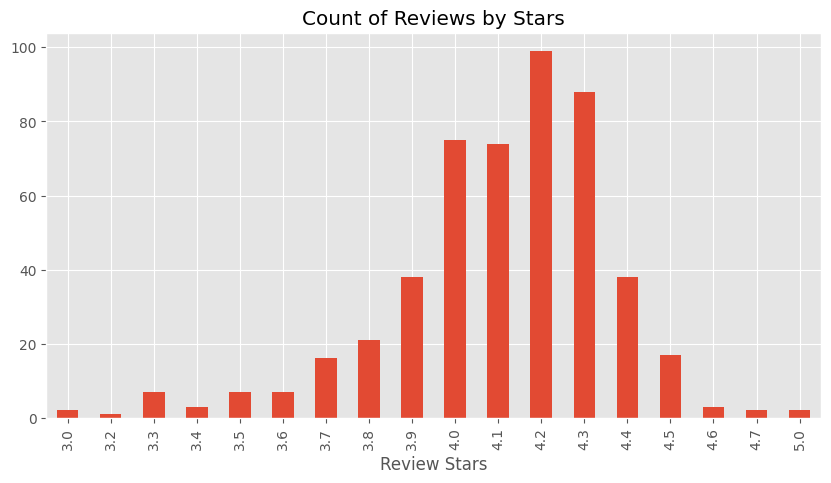

In [11]:
ax = df['rating'].value_counts().sort_index() \
    .plot(kind='bar',
          title='Count of Reviews by Stars',
          figsize=(10, 5))
ax.set_xlabel('Review Stars')
plt.show()

In [14]:
example = df['review_content'][50]
print(example)

I am using this on an old Mac Mini, since the Broadcom proprietary drivers aren't available and the replacement B43 drivers don't allow for sufficient download speeds, at least in my experience. I got this device up and running with Ubuntu 22.04 with Linux 5.15.0-56-generic.Google search for "morrownr/8821au-20210708" and use the driver on Github. I'm using the product "TP-Link AC600" btw. If you are using the other variant sold on Amazon, use lsusb and find out which network interface you are going to have to install drivers for. GIYF.I will admit, this is probably going to be hard for someone who is not generally comfortable with a shell, bash for example. But even though I had never used dkms or iw before, the Github repo along with the build tools available in the jammy repo made it easy enough to get the device working (read the GitHub Readme).To be sure I first got the drivers working in a local Ubuntu VM using Guest Additions to connect to the USB device directly from the guest 

In [15]:
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [16]:
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [17]:
tokens = nltk.word_tokenize(example)
tokens[:10]

['I', 'am', 'using', 'this', 'on', 'an', 'old', 'Mac', 'Mini', ',']

In [18]:
import nltk
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [19]:
nltk.download('averaged_perceptron_tagger_eng')


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [20]:
tagged = nltk.pos_tag(tokens)
tagged[:10]

[('I', 'PRP'),
 ('am', 'VBP'),
 ('using', 'VBG'),
 ('this', 'DT'),
 ('on', 'IN'),
 ('an', 'DT'),
 ('old', 'JJ'),
 ('Mac', 'NNP'),
 ('Mini', 'NNP'),
 (',', ',')]

In [21]:
import nltk

# Download everything required for NER (Named Entity Recognition)
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker_tab')  # for newer NLTK versions



[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

In [22]:
entities = nltk.chunk.ne_chunk(tagged)
entities.pprint()

(S
  I/PRP
  am/VBP
  using/VBG
  this/DT
  on/IN
  an/DT
  old/JJ
  (ORGANIZATION Mac/NNP Mini/NNP)
  ,/,
  since/IN
  the/DT
  (ORGANIZATION Broadcom/NNP)
  proprietary/JJ
  drivers/NNS
  are/VBP
  n't/RB
  available/JJ
  and/CC
  the/DT
  replacement/NN
  B43/NNP
  drivers/NNS
  do/VBP
  n't/RB
  allow/VB
  for/IN
  sufficient/JJ
  download/NN
  speeds/NNS
  ,/,
  at/IN
  least/JJS
  in/IN
  my/PRP$
  experience/NN
  ./.
  I/PRP
  got/VBD
  this/DT
  device/NN
  up/RB
  and/CC
  running/VBG
  with/IN
  (ORGANIZATION Ubuntu/NNP)
  22.04/CD
  with/IN
  (PERSON Linux/NNP)
  5.15.0-56-generic.Google/JJ
  search/NN
  for/IN
  ``/``
  morrownr/8821au-20210708/JJ
  ''/''
  and/CC
  use/VB
  the/DT
  driver/NN
  on/IN
  (GPE Github/NNP)
  ./.
  I/PRP
  'm/VBP
  using/VBG
  the/DT
  product/NN
  ``/``
  TP-Link/JJ
  (ORGANIZATION AC600/NNP)
  ''/''
  btw/NN
  ./.
  If/IN
  you/PRP
  are/VBP
  using/VBG
  the/DT
  other/JJ
  variant/JJ
  sold/VBN
  on/IN
  (GPE Amazon/NNP)
  ,/,
  use/NN
  ls

In [23]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm

sia = SentimentIntensityAnalyzer()

In [24]:
sia.polarity_scores('I am so happy!')

{'neg': 0.0, 'neu': 0.318, 'pos': 0.682, 'compound': 0.6468}

In [25]:
sia.polarity_scores('This is the worst thing ever.')

{'neg': 0.451, 'neu': 0.549, 'pos': 0.0, 'compound': -0.6249}

In [26]:
sia.polarity_scores(example)

{'neg': 0.055, 'neu': 0.848, 'pos': 0.098, 'compound': 0.9846}

In [28]:
res = {}

for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['review_content']           # correct column name
    myid = row['product_id']           # unique identifier (or just use i)
    res[myid] = sia.polarity_scores(str(text))  # convert to string in case of NaN

  0%|          | 0/500 [00:00<?, ?it/s]

In [30]:
vaders = pd.DataFrame(res).T
vaders = vaders.reset_index().rename(columns={'index': 'product_id'})  # Correctly rename to 'product_id'

vaders = vaders.merge(df, on='product_id', how='left')

In [31]:
# Now we have sentiment score and metadata
vaders.head()

,product_id,neg,neu,pos,compound,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,0.032,0.744,0.224,0.9033,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B07JW9H4J1,0.032,0.744,0.224,0.9033,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,270",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/I/51UsScvHQN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
2,B098NS6PVG,0.010,0.821,0.169,0.9853,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
3,B098NS6PVG,0.010,0.821,0.169,0.9853,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,993","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/I/31zOsqQOAO...,https://www.amazon.in/Ambrane-Unbreakable-Char...
4,B096MSW6CT,0.000,0.641,0.359,0.6808,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


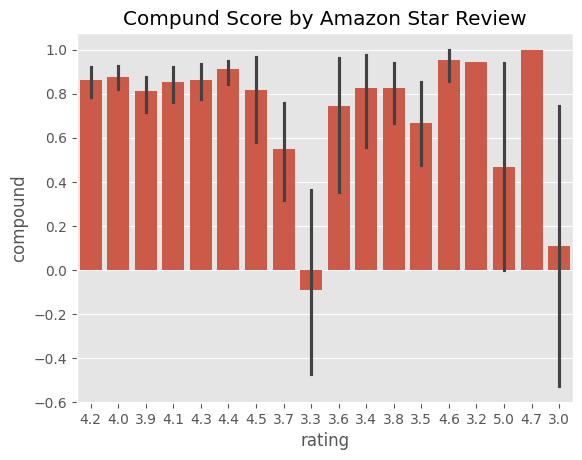

In [34]:
ax = sns.barplot(data=vaders, x='rating', y='compound')
ax.set_title('Compund Score by Amazon Star Review')
plt.show()

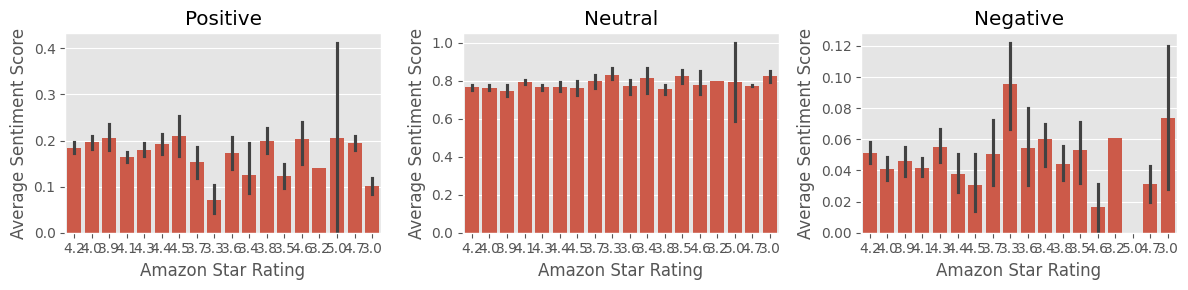

In [36]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3))

sns.barplot(data=vaders, x='rating', y='pos', ax=axs[0])
sns.barplot(data=vaders, x='rating', y='neu', ax=axs[1])
sns.barplot(data=vaders, x='rating', y='neg', ax=axs[2])

axs[0].set_title('Positive')
axs[1].set_title('Neutral')
axs[2].set_title('Negative')

for ax in axs:
    ax.set_xlabel('Amazon Star Rating')
    ax.set_ylabel('Average Sentiment Score')

plt.tight_layout()
plt.show()

In [37]:
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from scipy.special import softmax

In [44]:
MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

In [39]:
# VADER results on example
print(example)
sia.polarity_scores(example)

I am using this on an old Mac Mini, since the Broadcom proprietary drivers aren't available and the replacement B43 drivers don't allow for sufficient download speeds, at least in my experience. I got this device up and running with Ubuntu 22.04 with Linux 5.15.0-56-generic.Google search for "morrownr/8821au-20210708" and use the driver on Github. I'm using the product "TP-Link AC600" btw. If you are using the other variant sold on Amazon, use lsusb and find out which network interface you are going to have to install drivers for. GIYF.I will admit, this is probably going to be hard for someone who is not generally comfortable with a shell, bash for example. But even though I had never used dkms or iw before, the Github repo along with the build tools available in the jammy repo made it easy enough to get the device working (read the GitHub Readme).To be sure I first got the drivers working in a local Ubuntu VM using Guest Additions to connect to the USB device directly from the guest 

{'neg': 0.055, 'neu': 0.848, 'pos': 0.098, 'compound': 0.9846}

In [48]:
# Run for Roberta Model
encoded_text = tokenizer(example, return_tensors='pt', truncation=True, max_length=512)
output = model(**encoded_text)
sia_scores = output[0][0].detach().numpy()
scores = softmax(sia_scores)
scores_dict = {
    'roberta_neg' : scores[0],
    'roberta_neu' : scores[1],
    'roberta_pos' : scores[2]
}
print(scores_dict)

{'roberta_neg': np.float32(0.07261354), 'roberta_neu': np.float32(0.3598762), 'roberta_pos': np.float32(0.56751025)}


In [45]:
def polarity_scores_roberta(example):
    encoded_text = tokenizer(example, return_tensors='pt')
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    scores_dict = {
        'roberta_neg' : scores[0],
        'roberta_neu' : scores[1],
        'roberta_pos' : scores[2]
    }
    return scores_dict

In [50]:
res = {}

for i, row in tqdm(df.iterrows(), total=len(df)):
    try:
        text = str(row['review_content'])           # ✅ your text column name
        myid = row['product_id']                # ✅ your ID column (or use i)

        # VADER sentiment
        vader_result = sia.polarity_scores(text)
        vader_result_rename = {f"vader_{k}": v for k, v in vader_result.items()}

        # RoBERTa sentiment (assuming you've defined polarity_scores_roberta)
        roberta_result = polarity_scores_roberta(text)

        # Merge both model outputs
        both = {**vader_result_rename, **roberta_result}
        res[myid] = both

    except RuntimeError:
        print(f"Broke for id {myid}")
    except Exception as e:
        print(f"Error for id {myid}: {e}")

  0%|          | 0/500 [00:00<?, ?it/s]

Broke for id B08CF3B7N1
Broke for id B008IFXQFU
Broke for id B0B1YVCJ2Y
Broke for id B08B42LWKN
Broke for id B0B3MMYHYW
Broke for id B09JPC82QC
Broke for id B07232M876
Broke for id B07P681N66
Broke for id B0711PVX6Z
Broke for id B07MKFNHKG
Broke for id B0088TKTY2
Broke for id B09Q5SWVBJ
Broke for id B0B15CPR37
Broke for id B09RWZRCP1
Broke for id B09VCHLSJF
Broke for id B0B1YZX72F
Broke for id B092BJMT8Q
Broke for id B09Q5P2MT3
Broke for id B09T3KB6JZ
Broke for id B0B9XLX8VR
Broke for id B09RX1FK54
Broke for id B099K9ZX65
Broke for id B0B1YY6JJL
Broke for id B0859M539M
Broke for id B002SZEOLG
Broke for id B08CS3BT4L
Broke for id B0117H7GZ6
Broke for id B088Z1YWBC
Broke for id B081FG1QYX
Broke for id B0B1YZ9CB8
Broke for id B07MDRGHWQ
Broke for id B0B15GSPQW
Broke for id B07HZ2QCGR
Broke for id B095JQVC7N
Broke for id B09Q8WQ5QJ
Broke for id B081FJWN52
Broke for id B09WN3SRC7
Broke for id B0BC8BQ432
Broke for id B0BC9BW512
Broke for id B0978V2CP6
Broke for id B092BL5DCX
Broke for id B08

In [51]:
results_df = pd.DataFrame(res).T
results_df = results_df.reset_index().rename(columns={'index': 'product_id'})  # match key column
results_df = results_df.merge(df, on='product_id', how='left')

In [52]:
results_df.columns

Index(['product_id', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
       'roberta_neg', 'roberta_neu', 'roberta_pos', 'product_name', 'category',
       'discounted_price', 'actual_price', 'discount_percentage', 'rating',
       'rating_count', 'about_product', 'user_id', 'user_name', 'review_id',
       'review_title', 'review_content', 'img_link', 'product_link'],
      dtype='object')

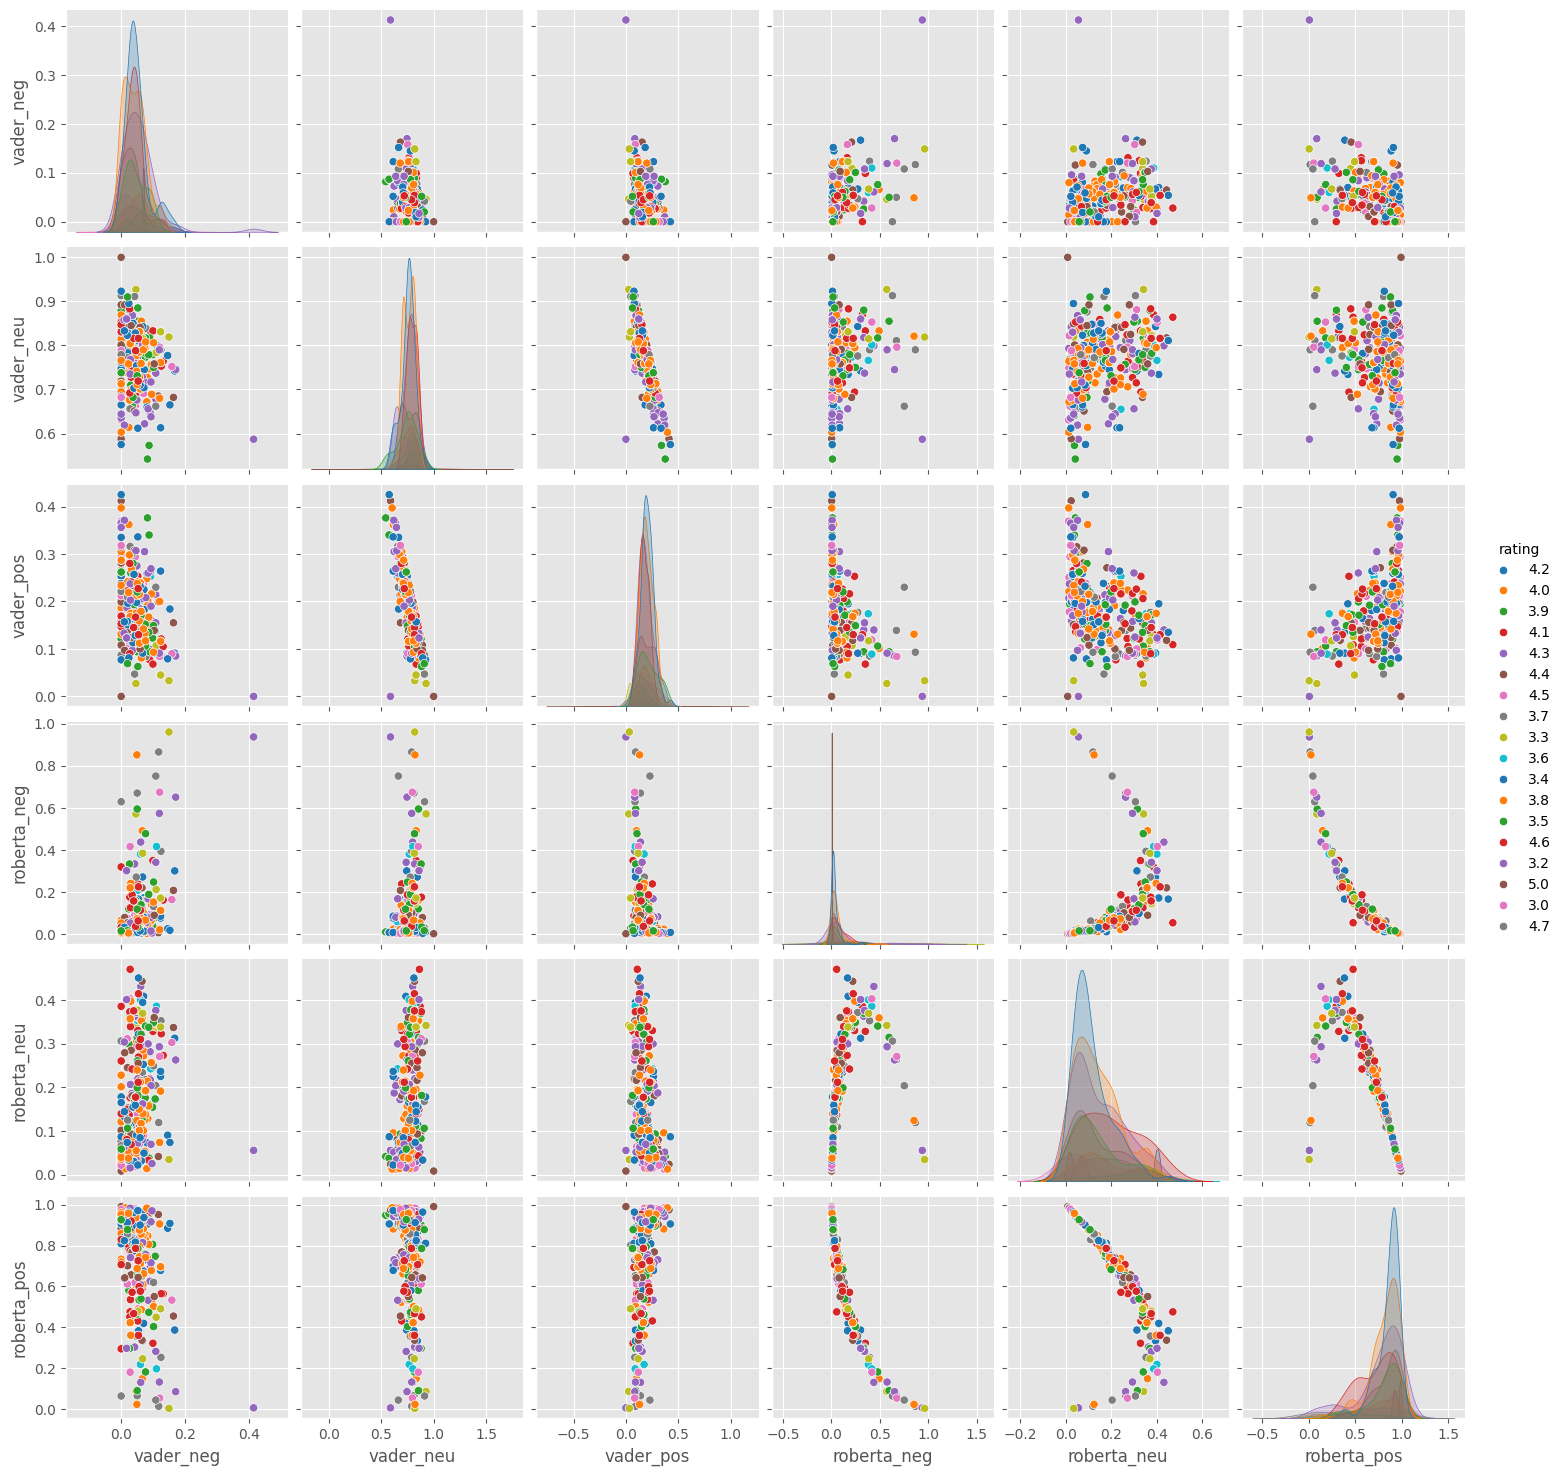

In [54]:
sns.pairplot(data=results_df,
             vars=['vader_neg', 'vader_neu', 'vader_pos',
                  'roberta_neg', 'roberta_neu', 'roberta_pos'],
            hue='rating',
            palette='tab10')
plt.show()

In [58]:
results_df.query('rating == "4.2"') \
    .sort_values('roberta_pos', ascending=False)['review_content'].values[0]

'I like the product and I used it for my iphone,The product got delivered fast. It surely does work for the price you pay for it. Does a good work of charging the iPhones without any lags. I will recommend. In fact bought a couple of other products too after taking this cable.,Its build quality is excellent and it charges the phone quickly despite being a long cable which is a good feature of it.,Nice product for rough use. I have been using this in my car since day one & it has taken all the weathering. Good product, zero hassles, zero complaint. Go for it!,Nice product☑️,Good and convenient product for those who don’t want long dangling wires from their power banks😊,I bought a Wayona One Plus cable and then this cable a few years later, never faced an issue. Recommended it to my friends as well, no one faced an issue with Wayona products thus far. Worth it.,Quality product  , Life of product is good  .'

In [61]:
results_df.query('rating == "3.9"') \
    .sort_values('vader_pos', ascending=False)['review_content'].values[0]

"It's a good product.,Like,Very good item strong and useful USB cableValue for moneyThanks to amazon and producer,https://m.media-amazon.com/images/I/51112ZRE-1L._SY88.jpg,Good,Sturdy but does not support 33w charging,Nice product and useful product,-"

In [63]:
# nevative sentiment 5-Star view

In [65]:
results_df.query('rating == "4.2"') \
    .sort_values('roberta_neg', ascending=False)['review_content'].values[0]

'https://m.media-amazon.com/images/I/71SaXlf9TZL._SY88.jpg,Small cable otherwise good,,I like the product.,Quality is good but after a month immediately I lose 9% of battery health so that’s why I stop using it,Not sturdy, cable will break in just weeks,i suggest this product,Nice'

In [68]:
results_df.query('rating == "4.2"') \
    .sort_values('vader_neg', ascending=False)['review_content'].values[0]

'https://m.media-amazon.com/images/I/71SaXlf9TZL._SY88.jpg,Small cable otherwise good,,I like the product.,Quality is good but after a month immediately I lose 9% of battery health so that’s why I stop using it,Not sturdy, cable will break in just weeks,i suggest this product,Nice'

In [72]:
# netural sentiment 5-Star view

In [71]:
results_df.query('rating == "4.2"') \
       .sort_values('vader_neu', ascending=False)['review_content'].values[0]

'Best but slow response from tv,Product is good,https://m.media-amazon.com/images/I/71Knz9n24GL._SY88.jpg,Value for money,Super quality....go with TCL,,Best price,చాలా బాగుంది కానీ యుాస్ బి పోర్ట్స్ లోపల కాకుండా బయటికి ఇస్తే బాగుంటుంది మరియు గుాగుల్ క్రోమ్ ఇన్ బుల్ట్ గా ఇస్తే బాగుంటుంది'

In [74]:
results_df.query('rating == "4.2"') \
        .sort_values('roberta_neu', ascending=False)['review_content'].values[0]

'Cable is working propely but the price is on a higher side.,Good Quality,Cable was too short,Hello everyone,Do not go for this .beacuse it says 5gbs transfer speed but it has a very slow speed in comparison to the original cable I got from Seagate company. my original cable shows the cut and copies speed to SSD like 30 to 150mbs ps per second. But this cable does around 10 to 80mbs  mostly. The cable is also very thin in size, the original Seagate had is very thick and sturdy.  At the end speed matters.so if u have like 2 or 4TB external hard drive it will load slowly after connecting, folders keep loading and loading. So, I would rather suggest to please go with a 10 GBS speed cable which will have a 3.1 type c cable.,Worth the money,Plug fits little tight to the port, might damage the port on longer use. But does the job well.,It is a good product. Works with all the laptops and hard drives. Value for money. Recomended product,GOOD'

In [75]:
from transformers import pipeline

sent_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


In [76]:
sent_pipeline('I love sentiment analysis!')

[{'label': 'POSITIVE', 'score': 0.9997853636741638}]

In [77]:
sent_pipeline('booo')

[{'label': 'NEGATIVE', 'score': 0.9936267137527466}]

In [78]:
sent_pipeline('i  dont hate you')

[{'label': 'POSITIVE', 'score': 0.8792605996131897}]

In [79]:
sent_pipeline('The product meets expectations but doesn’t stand out')

[{'label': 'NEGATIVE', 'score': 0.9676089286804199}]

In [80]:
sent_pipeline('It’s okay — not good, not bad')

[{'label': 'POSITIVE', 'score': 0.9987718462944031}]

In [81]:
sent_pipeline('It works, but file writes are a bit slower than expected on a USB3 reader')

[{'label': 'NEGATIVE', 'score': 0.9929641485214233}]

In [82]:
result = sent_pipeline("Still don't feel it is very fast or is just my phone, I guess I will need to remove it and run some R/W tests. Still, it's ok.")
print(result)


[{'label': 'POSITIVE', 'score': 0.9977243542671204}]
